# 1. 프로젝트: 고양이 수염 스티커 만들기

### 모듈 설치 및 버젼 확인

In [1]:
!pip install cmake opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [1]:
# 필요한 패키지 import 하기
import os
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
import cv2
import dlib

print(cv2.__version__)
print(dlib.__version__)

4.13.0
20.0.0


## 1. 이미지 로드 해오기.

홈 디렉토리 설정과 로드할 경로 지정

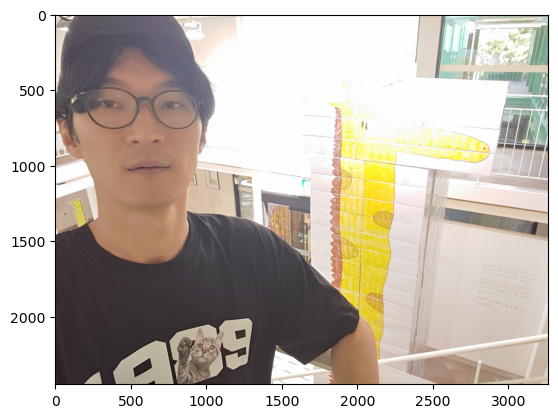

In [3]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/human.png') # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  ### bgr => RGB로 변환
img_show = img_rgb.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_rgb) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

이미지 사이즈 작게 지정

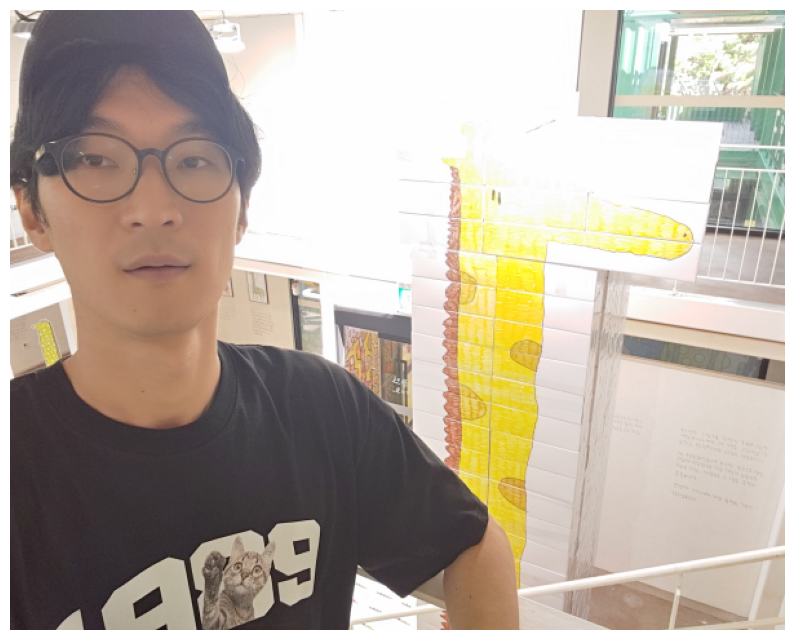

In [4]:
width = 600
height = 480
dsize = (width, height)

# interpolation=cv2.INTER_AREA는 이미지를 줄일 때 화질 저하를 최소화하는 알고리즘입니다
img_resized = cv2.resize(img_show, dsize, interpolation=cv2.INTER_AREA)
img_reshow = img_resized.copy()
plt.figure(figsize=(10, 15)) # 출력 창 크기도 조절
plt.imshow(img_resized)
plt.axis('off') # 격자 숨기기
plt.show()

얼굴감지기 설정

In [5]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
dlib_rects = detector_hog(img_resized, 1)   # 이미지를 얼굴감지기에 올려준다 (image, num of image pyramid)

rectangles[[(29, 81) (184, 236)]]


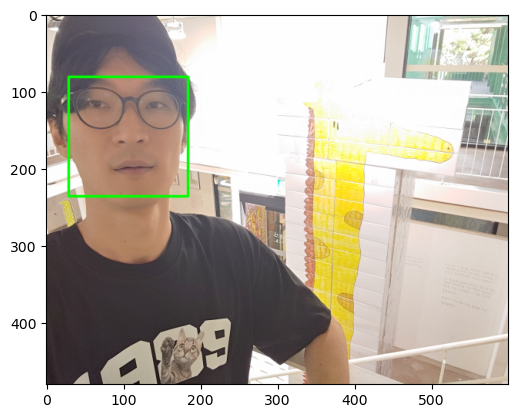

In [6]:
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_resized, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

plt.imshow(img_resized)
plt.show()

### 얼굴감자기가 찾은 좌상단좌표와 우하단좌표
left : 29  
top : 81  
right : 184  
bottom : 236

## 2. 눈코입 랜드마크에 포인트 찍기

### 모델 셋업

In [7]:
 !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
 !mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
 !cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-04-20 07:09:53--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-20 07:09:53--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  16.3MB/s    in 4.1s    

2026-04-20 07:09:58 (14.8 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [8]:
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)

랜드마크 리스트 설정과 위치 정보를 좌표로 변화하여 포인트 찍기

In [9]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_resized, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


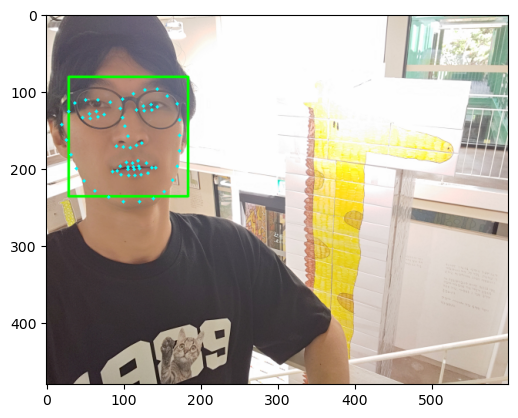

In [10]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_resized, point, 2, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

    # RGB 이미지로 전환
plt.imshow(img_resized)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

In [11]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[30]) # 코의 index는 30 입니다
    x = landmark[30][0] # 이미지에서 코 부위의 x값
    y = landmark[30][1] - dlib_rect.height()//2 # 이미지에서 코 부위의 y값 - 얼굴 영역의 세로를 차지하는 픽셀의 수//2 → (437, 182-(186+1//2))
    w = h = dlib_rect.width() 
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(106, 158)
(x,y) : (106,80)
(w,h) : (156,156)


### 스티커 이미지 불러오기

In [13]:
sticker_path = os.path.join(home_dir, 'work/AIFFEL_quest_eng/Computer_Vision/CV01/cat.png') 
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w,h))
print (img_sticker.shape) 

(156, 156, 3)


스티커 붙이기

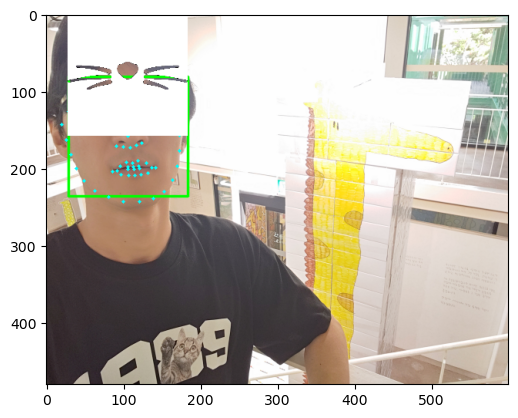

In [14]:
refined_x = x - w // 2 
refined_y = y - h // 2

if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
# 
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :] # 
    refined_y = 0

sticker_area = img_resized[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]

img_resized[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)

plt.imshow(img_resized)
plt.show()

왕관 코드를 그대로 사용하여 스피커가 이마에 붙는 문제 발생.  
x = landmark[30][0] 처음 X값이 코 정중앙이라서 그런거 같다.  
코 위치에서 왼쪽 위 꼭지점에서 이미지가 시작되어야 한다.

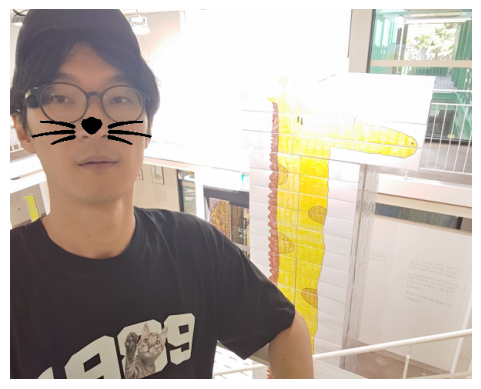

In [15]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # 얼굴 영역의 가로 길이를 기준으로 스티커 크기를 정합니다.
    w = dlib_rect.width()
    h = dlib_rect.width() # 가로세로 비율이 1:1
    
    # 스티커 리사이즈
    img_sticker_resized = cv2.resize(img_sticker, (w, h))

    # 코의 위치 (landmark[30])를 중심으로 잡습니다.
    # x, y는 스티커가 시작되는 '왼쪽 위 꼭짓점' 좌표여야 합니다.
    x = landmark[30][0] - w // 2  # 코 중앙에서 가로 절반만큼 왼쪽으로
    y = landmark[30][1] - h // 2  # 코 중앙에서 세로 절반만큼 위쪽으로 (수염 위치)

    # 이미지 경계를 벗어나는지 체크
    if x < 0: x = 0
    if y < 0: y = 0
    if x + w > img_reshow.shape[1]: w = img_reshow.shape[1] - x
    if y + h > img_reshow.shape[0]: h = img_reshow.shape[0] - y
    
    # 조절된 크기에 맞춰 다시 리사이즈 (경계면에 걸친 경우 대비)
    img_sticker_resized = cv2.resize(img_sticker, (w, h))

    # --- 합성 영역(ROI) 추출 ---
    sticker_area2 = img_reshow[y:y+h, x:x+w]

    # --- np.where를 이용한 배경 제거 합성 ---
    # 이미지 결과에서 본 것처럼 배경이 흰색(255)이므로 250보다 큰 값을 배정.
    img_reshow[y:y+h, x:x+w] = np.where(img_sticker_resized > 250, sticker_area2, img_sticker_resized).astype(np.uint8)

plt.imshow(img_reshow)
plt.axis('off')
plt.show()

얼굴 각도에 따라서 눈쪽 랜드마크가 잘못 찍히는거 같다.